# Nanoparticle simulation

# Introduction

(*Text here and in the background section is partially taken from the [article by Luka Monticelli et al](https://doi.org/10.1038/nnano.2008.130)*)

Recent toxicology studies suggest that nanosized aggregates of fullerene molecules can enter cells and alter their functions, and also cross the blood–brain barrier. However, the mechanisms by which fullerenes penetrate and disrupt cell membranes are still poorly understood. Here we use computer simulations to explore the aggregation of fullerenes, translocation of their clusters through a model lipid membrane and the effect of high fullerene concentrations on membrane properties. We will also analyse the free energy profiles for a single fullerene entering/leaving the membrane.

# Background

The mechanism of nano-C60 penetration through a lipid membrane has not yet been established. The mechanism of cell membrane disruption is also not well understood. In the original study by Monticelli et al, the authors describe the thermodynamics and mechanism of the permeation of fullerene aggregates through cell membranes, based on computer simulations. They developed a coarse-grained (CG) model based on experimental partitioning of fullerene between polar and non-polar phases. The original work, as well as its repetition in this lab, provides insight into the thermodynamics of fullerene clusters permeation through cell membranes and the effect of high concentrations of fullerene on the structural and elastic properties of a lipid bilayer.

# Important:

Before start with this lab:

Go to the menu 'Runtime' and select the option 'Change runtime type'.

Then select 'T4 GPU' under the hardware accelerator options: 

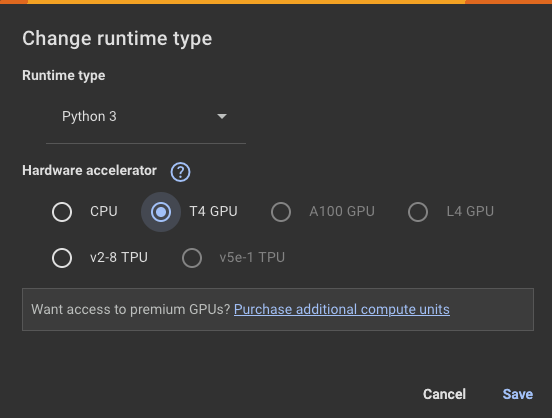

# Setting up the environment (common for all)

In [ ]:
# Installing necessary packages
!pip install py3Dmol

In [ ]:
# Cloning the course repository
!git clone https://github.com/computationalpharmaceutics/3FG005.git

In [ ]:
import os
os.chdir('/content/3FG005/Lab04_Nanoparticles')
!ls -l

In [ ]:
# If GPU available, copying the gromacs_intall.tar.gz file from the path to the content file
!cp /content/3FG005/Lab01_peptide_aggregation/GROMACS_GPU_T4/gromacs_install.tar.gz /content

In [ ]:
# Unpacking the file gromacs_install.tar.gz  and creating the folder:  /usr/local/gromacs
!tar -xzf /content/3FG005/Lab01_peptide_aggregation/GROMACS_GPU_T4/gromacs_install.tar.gz -C /

In [ ]:
# Confirm it's installed
!/usr/local/gromacs/bin/gmx --version

In [ ]:
# Seting the path to GROMACS
import os
os.environ["PATH"] += ":/usr/local/gromacs/bin"

# Looking for the working directory
!pwd

In [ ]:
!apt-get update && apt-get install -y packmol

# Part 1: Simulation of the fullerene molecules in water

In this part of the lab, we want to observe the behavior of fullerenes in water. Specifically, we aim to determine whether the molecules aggregate. This section also serves as good practice for several common routines in MD simulations. In previous exercises, you already used some GROMACS commands, such as gmx grompp and gmx mdrun. It is crucial to check the output of these commands and review any warning or error messages, as ignoring them could result in unphysical results. However, simulations can also be run more automatically by using a script to handle the sequence of commands.

First, let's prepare the input files for the simulation. The fullerene molecule can be found in the supplementary material of the original paper. It is also available in the archive containing the simulation files. 

In [ ]:
# Changing the working directory to

import os
os.chdir('/content/3FG005/Lab04_Nanoparticles/Part1') # REPLACE
!pwd

In [ ]:
# Remove temporary files from the folder (if there are any)
!rm *#*

In [ ]:
# First let's take a look at the files available in the directory
!ls -l

The first file is called F16.pdb. You can view its contents with any text editor (vim, nano, atom, nedit, gedit, etc.) available on your computer or virtual machine. As you probably already know, pdb files contain coordinates for each bead representing the molecule. There may also be additional information (please see [the format here](https://en.wikipedia.org/wiki/Protein_Data_Bank_(file_format)) if you're interested), but we won't focus on that here.

In [ ]:
# The following command will show the contents of the file F16.pdb (coordinates
# of the atoms in the fullerene molecule).

!cat F16.pdb

Another important file is called F16.itp. It is a topology file that describes the types of beads used for that specific molecule from the force field (FF), as well as how the atoms are bonded to each other (harmonic, angular bonds, and dihedrals). Additional information, including illustrative videos of dihedrals, can be found on [the CHARMM FF webpage](https://www.charmm-gui.org/?doc=lecture&module=scientific&lesson=9).

The force field we will use is called Martini. It is one of the most common coarse-grained (CG) force fields. Each bead in Martini version 2 typically represents 4 heavy atoms, which reduces the number of beads needed to simulate the system and allows for larger time steps during simulation. For more information, please check [the official MartiniCG webpage](http://cgmartini.nl/index.php/about).

If you want to hide the output of a command (to prevent scrolling when navigating the notebook), you can click on the arrow symbol at the beginning of the output cell and select "show/hide output".

In [ ]:
!cat F16.itp

For this first simulation, we will only need two types of molecules: fullerene and water. We will place **30 nanoparticles** and **4000 water molecules** into a relatively small simulation box (6 x 6 x 6 nm). In previous labs, you used commands like gmx insert-molecules and gmx solvate to set up the system. Here, we will use an alternative method, specifically software called "Packmol, " which can arrange molecules without overlapping. An example of the input file (input.packmol) is included in the Part1 folder. It shows the command blocks that define the system components, specify the number of molecules, and describe their initial distribution within the box.

In [ ]:
!cat input.packmol

In [ ]:
!packmol < input.packmol

Once the system is assembled, a new pdb file will be created in that folder—pay attention to the output in the terminal, where the new .pdb file will be mentioned at the end. Alternatively, you can open the input.packmol file and see the name of the new file in the output filename field (you can find the *!cat input.packmol* cell above or create a new one and run it). Use this name (without the extension) from now on instead of "filenameX." To continue the simulation, you need to add the box borders to the introduced molecules. The simplest way to do this is to use **gmx editconf** with the **-d** option. This creates the box boundary with an offset (in our case, 0.1 nm) from the most remote atoms in each direction. As a result, the box borders will be placed 0.1 nm away from the leftmost atom (in X dimension), 0.1 nm away from the rightmost atom, and similarly for all six walls of the box. The **-c** option in the command centers the center of mass of the molecules within the newly created box.

In [ ]:
# Replace the "filenameX" parts with the actual file name of the output
# from packmol ("Solution: fullerenes_water.pdb").
# If you are getting an error, you need to check the filenames.

!gmx editconf -f filenameX.pdb -o filenameX.gro -c -d 0.1


#!gmx editconf -f fullerenes_water.pdb -o fullerenes_water.gro -c -d 0.1

Besides that, we need to create an index file for the contents of the box. This can be done with the command **gmx make_ndx**. By default, the output file will be named *index.ndx*. **Follow the instructions that appear on your screen to complete the command. You will need to save the suggested structure by typing "q" and pressing Enter.**

In [ ]:
# Remember to replace filenameX with the qactual filename
!gmx make_ndx -f filenameX.gro

# Solution
# !gmx make_ndx -f fullerenes_water.gro

Once that's done, we just need to verify that the contents of the newly built system match those described in the system.top file. Use the lines below to ensure the order of the molecules is the same as in the input.packmol file you used.

In [ ]:
!echo -e "What we compiled with packmol:\n"
!cat input.packmol
!echo -e "\nWhat we specified in system.top:"
!tail -n 5 system.top

If everything is correct, the numbers for F16 and W will match in both files; otherwise, we will need to adjust them in one of the files.

Now, let's perform one step of the simulation as usual. Set up the first simulation stage with gmx grompp and gmx mdrun. **Remember to replace the filenames with the actual file names!**

In [ ]:
# Remember to replace filenameX with the actual filename
# Setting up the executable file for the minimization step of the simulation
!gmx grompp -f step6.0_minimization.mdp -o step6.0_minimization.tpr -c filenameX.gro -r filenameX.gro -p system.top -n index.ndx

# Solution
# !gmx grompp -f step6.0_minimization.mdp -o step6.0_minimization.tpr -c fullerenes_water.gro -r fullerenes_water.gro -p system.top -n index.ndx

In [ ]:
# Let's run the minimization for our molecules
!gmx mdrun -nt 1 -deffnm step6.0_minimization

Check the output of the commands - were there any errors or warnings? Notes are usually harmless, just informing you about what was adjusted in your input by GROMACS.

Ensure the commands worked correctly and that you received the file step6.0_minimization.gro as a result.

In [ ]:
# prompt: if step6.0_minimization.gro is present, print "step6.0_minimization.gro is created", otherwise "either it is still running or there must be an error in the cell above"

if os.path.exists('step6.0_minimization.gro'):
  print("File step6.0_minimization.gro is created")
else:
  print("either it is still running or there must be an error in the cell above")

Let's see if the energy has reached a plateau. The following command will allow you to input a number that corresponds to the potential energy. When prompted, type '4 0' to select Potential (4, but double-check when you run the command); and zero (0) terminates input. This will generate a file named 'potential.xvg'.

In [ ]:
# Obtaining the energy minimization profile
!gmx energy -f step6.0_minimization.edr -o potential.xvg

In [ ]:
# Plot the energy profile from the minimization step
import matplotlib.pyplot as plt
import numpy as np
import os

# Define the path to your .xvg file
xvg_file = 'potential.xvg'

# Check if the file exists
if not os.path.exists(xvg_file):
    print(f"Error: {xvg_file} not found. Make sure the file exists.")
else:
    # Read the data from the .xvg file
    # We need to skip lines that start with # or @ as they are comments or metadata
    data = []
    with open(xvg_file, 'r') as f:
        for line in f:
            line = line.strip()
            if not line.startswith(('#', '@')) and line:
                try:
                    # Split the line and convert values to float
                    x, y = line.split()
                    data.append([float(x), float(y)])
                except ValueError:
                    # Handle potential errors if a line doesn't have two numbers
                    print(f"Skipping line due to parsing error: {line}")

    # Convert the list of lists into a NumPy array
    data = np.array(data)

    # Check if any data was read
    if data.size > 0:
        # Extract the columns (time and potential energy)
        time = data[:, 0]
        potential_energy = data[:, 1]

        # Plot the data
        plt.figure(figsize=(10, 6)) # Optional: Set the figure size
        plt.plot(time, potential_energy)

        # Set the y-axis to a logarithmic scale
        plt.yscale('log')

        plt.xlabel('Time (ps)') # Update with the correct unit from your .xvg file if different
        plt.ylabel('Potential Energy (kJ/mol)') # Update with the correct unit
        plt.title('Potential Energy Minimization Profile (Log Scale)')
        plt.grid(True) # Optional: Add a grid
        plt.show()
    else:
        print(f"No valid data found in {xvg_file} to plot.")

It is just one of the steps needed to equilibrate the system, but there should be many more to gradually increase the timestep. Additionally, one must use the output from the previous step as input for the next one, so it’s important to stay focused. An alternative method we could use in the remaining exercises is to run the script instead. A script is a set of commands executed according to programming rules. Feel free to open the script file **Run_equilibration.sh** and review its structure. You will see several instances where gmx grompp and gmx mdrun are run. They are even executed within a “while” loop, meaning the body of the loop runs as long as the condition is met (that all 6 steps of the equilibration are completed). The purpose of that script is to automate the simulation process and perform repetitive steps without manual effort.

In [ ]:
# Take a look at the script that will streamline the process of several
# quilibration steps in order to prepare the system for the production run

!cat Run_equilibration.sh

As you progress from one step to another, the timestep (“dt” in the .mdp files) in the simulations will be increased, and some other parameters will eventually change. Such scripts are typically generated by additional software (like CHARMM-GUI in this case) or written manually. If there is a setup that is common across many simulations, it can also serve as a time-saving tool (for example, if you need to run the same simulation at different concentrations or with various nanoparticle or drug molecules - the sequence of steps would often be the same).

In [ ]:
# Check the timsestep for integration in MD at various equilibration steps
!grep "dt" step*.mdp

In [ ]:
# Run the script that will execute a sequence of molecular dynamics (MD)
# equilibration steps

# Remember that you can hide/show outputs using the arrow at hte top left corner
# of the cell output bellow

import time

start_time = time.time()

!bash ./Run_equilibration.sh

end_time = time.time()
elapsed_time = end_time - start_time

print(f"\nSystem equilibration completed in {elapsed_time:.2f} seconds.")

Ok, now the system is balanced, and we can review it at the start and end of the equilibration before moving on to the full-scale production run. Let’s omit the water molecules and focus only on the fullerenes. To do that, we can make copies of the .gro files, but with only F16 selected.

In [ ]:
# Make a copy of the pre-equilibrated box for fullerens only
!gmx editconf -f step6.2_equilibration.gro -n index.ndx -o fullerens_only.pdb -c


In [ ]:
# Visualise the system without water
import py3Dmol
with open('fullerens_only.pdb', 'r') as f:
    pdb_data = f.read()

view = py3Dmol.view(width=600, height=400)
view.addModel(pdb_data, 'pdb')
view.setStyle({'sphere': {'color': 'spectrum'}})
view.addUnitCell()
view.zoomTo()
view.show()

In [ ]:
# Make a copy of the equilibrated box for fullerens only
!gmx editconf -f step7_production.gro -n index.ndx -o fullerens_only_final.pdb -c

In [ ]:
# Visualise the system without water
import py3Dmol
with open('fullerens_only_final.pdb', 'r') as f:
    pdb_data = f.read()

view = py3Dmol.view(width=600, height=400)
view.addModel(pdb_data, 'pdb')
view.setStyle({'sphere': {'color': 'spectrum'}})
view.addUnitCell()
view.zoomTo()
view.show()

Hopefully, you can see that even during the equilibration step, some of the fullerenes had enough time to interact with each other.

However, we need to analyze a trajectory over a longer period of time, starting after the temperature and pressure equilibration (which was completed during the last few steps). To save time in the lab, the simulation has already been performed, and you should use the pre-run production simulation output, specifically the final molecules' trajectory file. **In the folder Part1 from the Studium page of the exercise**, you will find multiple files with the extension ".gro", representing several simulation equilibration steps and the file step7_production.

In the next part of the exercise, you need to upload the .gro file after equilibration and the final trajectory file (step7_production.xtc) to VMD. Many of you already know how to do this. If not, feel free to ask questions. To briefly describe the process: open VMD, go to the menu, select "File - New Molecule," then choose the file. After uploading the first molecule, you can select it in the list in the "VMD Main" window by clicking on it (it will turn grey), and then choose "File - Load Data into Molecule" to add more configurations.   


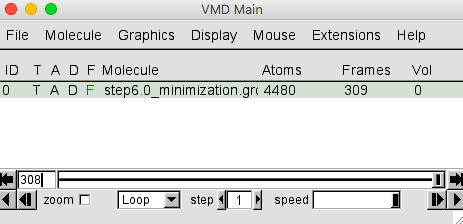

Once you have uploaded the molecule and the trajectory to VMD, try changing the representation of the fullerene molecules to VDW so you can clearly see whether the fullerene molecules aggregate in water. Go to “Graphics” → “Representations” and create a new replica of the system by clicking “Create rep”. Then, change the representation of the molecules in that replica by selecting “VDW” as the drawing method. You will notice that all the beads are now represented with balls instead of just points. Next, in the text input field, replace “all” with “resname F16” and press “Enter”. This makes only the fullerene molecules (called F16 here) display as balls. Another way to improve visualization is to set the representation to orthographic. Go to the “Display” menu and select “Orthographic” from the list. There are additional options, such as color schemes and different representation types, that you can explore. Most importantly, you need to clearly see whether the fullerene molecules aggregate by the end of the simulation. You can run the whole trajectory by pressing the play button in the lower-left corner. It is also possible to rotate the entire system by clicking and dragging in the main visualization window.

***Get a final snapshot of the simulation. Explain if the result is expected i.e., whether fullerene is supposed to be aggregated?***

# Part 2: Simulation of fullerenes next to the membrane

In this section, we will simulate a basic membrane model in the presence of fullerene nanoparticles. Membranes can often be built using existing tools and scripts, such as with Packmol (feel free to read Part 1, where it is described in more detail). However, in this lab, we will not focus on creating a membrane. Interested readers are encouraged to review [Justin Lemkul's tutorial on a membrane-protein system](http://www.mdtutorials.com/gmx/membrane_protein/index.html) with Gromacs.

It is also helpful (but not required right now) to learn how to build your own membrane using [CHARMM-GUI tool, though registration on the website is necessary](https://charmm-gui.org/?doc=input/martini.bilayer).

You can download the Part2 archive from the lab's studium page and extract it on your laptop or from a virtual server. For the latter, you can install Microsoft Remote Desktop if you haven't already and log in to the server its-srv045.its.uu.se using your student ID and password A. This remote server runs a Linux-based environment, where VMD is already installed, and you can use the browser just like on your laptop.

We will do some parts of the work here, in jupyter notebook and some in VMD on your laptop/remote desktop.

Let's start with looking at the membrane, already compiled with CHARMM-GUI, the file is called "dopc_bilayer.gro".

In [ ]:
# Change to the Part 2 directory
import os
os.chdir('/content/3FG005/Lab04_Nanoparticles/Part2')
!pwd

In [ ]:
# See what is in the head and tail of the membrane file

!echo -e "First ten lines:\n"
!head -n 10 dopc_bilayer.gro
!echo -e "\n Last ten lines:\n"
!tail -n 10 dopc_bilayer.gro

As you can see, the file contains both DOPC (phospholipid) and water (W) molecules. The last six columns represent coordinates in XYZ space and the rotation of the molecules around their respective axes.

Now, let's visualize it here in Colab.


In [ ]:
# Visualise the whole system
import py3Dmol
with open('dopc_bilayer.gro', 'r') as f:
    pdb_data = f.read()

view = py3Dmol.view(width=600, height=400)
view.addModel(pdb_data, 'gro')
view.setStyle({'sphere': {'color': 'spectrum'}})
view.addUnitCell()
view.zoomTo()
view.show()

It is probably not as clear as it could be, so at this stage, you are advised to either check how only the lipids would look or load the molecules into VMD and experiment with visualization settings.

In [ ]:
# Visualise the lipids only
import py3Dmol
with open('dopc_bilayer.gro', 'r') as f:
    pdb_data = f.read()

view = py3Dmol.view(width=600, height=400)
view.addModel(pdb_data, 'gro')
view.setStyle({'resn': 'DOPC'}, {'sphere': {'color': 'spectrum'}})
#view.setStyle({'resn': 'DOPC'}, {'sphere': {'color': 'yellow'}})
#view.setStyle({'resn': 'W'}, {'sphere': {'color': 'blue'}})
view.addUnitCell()
view.zoomTo()
view.show()

If you do visualization with VMD, first open the file with the gro extension from the gromacs subdirectory of the Part2 folder. One way to open it is by typing "vmd" in the terminal and pressing Enter. Once the window opens, you can upload the files through the menu "File-New Molecule" and then select the file. After uploading the first file, you can select the molecule in the list within the "VMD Main" window by clicking on it (it will turn grey; see the screenshot in Part 1), and choose "File-Load Data into Molecule" to add more configurations. After uploading the trajectory, change the molecule representations so the membrane is clearly visible. Go to "Graphics" -> "Representations," create a new replica by clicking "Create rep," and then change the representation of the molecules in that replica to "VDW," which will display all the beads as spheres instead of points. You can rotate the system in the main window (usually the black screen). Then, in the text input field, replace "all" with "resname DOPC" and press Enter. This will display only the membrane molecules (DOPC) with spherical beads, while the other molecules (water) remain as dots. To see the simulation box borders, go to the Extensions menu in VMD and select Tk Console. In the command line that appears, type "pbc box" and press Enter; the borders, depicted with blue lines, will be displayed.

As you can see from both VMD and the Colab visualization, there isn’t much space in the box to fit fullerenes, especially if you’re using the VDW representation for the molecules. Therefore, we will need to use a slightly modified version of the **gmx insert-molecules** command. Check the GROMACS manual for this command. Is there a way to replace some of the existing molecules with fullerenes? Reading manuals is an essential part of computer simulations, particularly in the early stages. We strongly recommend you try to find a solution on your own before proceeding further in the tutorial. Here’s a tip: we will replace water molecules with fullerenes because we don’t want to introduce the nanoparticles artificially by directly plugging them into a membrane.

In [ ]:
#The command you are expected to write here is:

!gmx insert-molecules -f dopc_bilayer.gro -ci F16.gro -o F16_and_membrane.gro -replace W -nmol 10

#where 10 is the number of the nanoparticles for insertion.

In this example, 10 fullerenes were inserted instead of approximately 40-50 water molecules. It mentions atoms, but it actually refers to coarse-grained beads, each representing more than one atom. In your case, the number of water molecules replaced by fullerenes may vary. Check the lines at the end of the output carefully:

*Added 10 molecules (out of 10 requested)*

*Replaced X residues (X atoms)*

Now you would have everything ready to run the script that would equilibrate the system. Take a look at the new system.

In [ ]:
# Visualise the system with F16

import py3Dmol
with open('F16_and_membrane.gro', 'r') as f:
    pdb_data = f.read()

view = py3Dmol.view(width=600, height=400)
view.addModel(pdb_data, 'gro')
view.setStyle({'sphere': {'color': 'spectrum'}})
view.setStyle({'resn': 'F16'}, {'sphere': {'color': 'white'}})

view.addUnitCell()
view.zoomTo()
view.show()

To visualize it with VMD, upload the file and set POPC and membrane as VDW in the Graphics menu - Representations. Create two more replicas, and replace in one of them “all” with “resname F16” and in the other “all” with “resname DOPC.” Then, change the drawing method to “VDW” for both. Now, you should see the same system as before, but with some fullerenes added.

Now, it is time to run the script that will gradually equilibrate the system and generate the trajectory files with the fullerene near the membrane. However, we will only perform the equilibration here and use pre-run files for the production step to simplify the process.

First, we need to update the .top file with the correct system topology to match the .gro file. Let’s check how many water and other molecules are in the .gro file, then adjust the random numbers in the .top file accordingly.

In [ ]:
# We can count the number of W by simlpy making a new index file, where those
# would be counted. Mind that the numbers written stand for beads, not for the
# molecules, so we have 10 fullerens (if you used the default number), not 160.

# Just type in "q" and Enter as you are in the interactive regime of the
# command.
!gmx make_ndx -f F16_and_membrane.gro -o index.ndx


Do you see how many water it was?

In [ ]:
# The current numbers of the molecules can be printed with tail command (as the
# lines with the numbers are in the nd of the .top file)
!tail system.top

As you can see, the number of water and fulleren (F16) molecules should be adjusted, while DOPC is 128 (with each lipid represented by 14 beads), resulting in the correct 1792, as shown by the make_ndx command.

To change the numbers, we can use the "sed" command to replace the existing value (e.g., 25 for F16) with the actual one (10), and the same for W.

In [ ]:
!sed -i -e "s/F16 25/F16 10/g" system.top
!sed -i -e "s/W 1395/W 1456/g" system.top
!tail system.top

Now that .top and .gro have the same information about the molecules in the system, we can run the minimization step, just in case we caused some random overlaps by inserting the fullerenes into the system.

In [ ]:
# Run minimization on the assembled system

!gmx grompp -f step6.0_minimization.mdp -o step6.0_minimization.tpr -c F16_and_membrane.gro -r F16_and_membrane.gro -p system.top -n index.ndx -maxwarn 5
!gmx mdrun -deffnm step6.0_minimization

!gmx grompp -f step6.1_minimization.mdp -o step6.1_minimization.tpr -c step6.0_minimization.gro -r F16_and_membrane.gro -p system.top -n index.ndx -maxwarn 5
!gmx mdrun -deffnm step6.1_minimization

Great, now let’s equilibrate the system by gradually increasing the timestep in a few steps. It’s important to use the output of the previous step as the input for the next one, so staying focused while doing this manually is crucial. Alternatively, we can use a script instead. A script is a set of commands executed according to programming rules. Feel free to open the script file **Run_equilibration.sh** and examine its structure. You’ll notice that it runs several instances of gmx grompp and gmx mdrun. These are even run inside a “while” loop, which means the loop’s body executes as long as the condition is met—that all six equilibration steps are completed. The purpose of this script is to automate the simulation process and perform the repetitive steps without manual effort.

In [ ]:
# Take a look at the script that will strealine the process of several
# quilibration steps in order to prepare the system for the production run

!cat Run_equilibration2.sh

As you progress from one step to the next, the timestep (“dt” in the .mdp files) in the simulations will increase, and some other parameters may change over time. These scripts are usually generated either by additional software (such as CHARMM-GUI in this case) or written manually. If a setup is common for many simulations, it can also serve as a time-saving tool (for example, when you need to run the same simulation at different concentrations or with various nanoparticle or drug molecules—the sequence of steps would often be the same).

In [ ]:
# Check the timsestep for integration in MD at various equilibration steps
!grep "dt" step*.mdp

In [ ]:
# Run the script that will execute a sequence of molecular dynamics (MD)
# equilibration steps

# Remember that you can hide/show outputs using the arrow at hte top left corner
# of the cell output bellow

import time

start_time = time.time()

!bash ./Run_equilibration2.sh

end_time = time.time()
elapsed_time = end_time - start_time

print(f"\nSystem equilibration completed in {elapsed_time:.2f} seconds.")

Ok, now the system is balanced, and we can examine it at both the beginning and the end of equilibration, before starting the full-scale production run. Let’s omit the water molecules to focus only on the fullerenes and DOPC. To do this, we can either use a different visualization style for the lipids than spheres or adjust the bead styles for each replica in VMD in a more flexible way.

In [ ]:
# Make a copy of the pre-equilibrated box for fullerens only

# First, let's make a new selection by inserting "2 | 4" in the input field,
# followed by "q".
!gmx make_ndx -f step6.2_equilibration.gro -o index.ndx

# Then we can make the system to only include the newly created group of DOPC
# and F16 (type in the group two times)
!gmx editconf -f step6.2_equilibration.gro -n index.ndx -o fullerens_and_DOPC.pdb -c


In [ ]:
# Visualise the system without water
import py3Dmol
with open('fullerens_and_DOPC.pdb', 'r') as f:
    pdb_data = f.read()

view = py3Dmol.view(width=600, height=400)
view.addModel(pdb_data, 'pdb')
view.setStyle({'cross': {'color': 'spectrum', 'opacity': 1.0}})
view.setStyle({'resn': 'F16'}, {'sphere': {'color': 'spectrum', 'opacity': 1.0}})
view.addUnitCell()
view.zoomTo()
view.show()

In [ ]:
# Same, as before: include the newly created group of DOPC
# and F16, use the group DOPC_F16, likely 5.
!gmx editconf -f step6.6_equilibration.gro -n index.ndx -o fullerens_and_DOPC_eq_final.pdb -c


In [ ]:
# Visualise the system without water
import py3Dmol
with open('fullerens_and_DOPC_eq_final.pdb', 'r') as f:
    pdb_data = f.read()

view = py3Dmol.view(width=600, height=400)
view.addModel(pdb_data, 'pdb')
view.setStyle({'cross': {'color': 'spectrum', 'opacity': 1.0}})
view.setStyle({'resn': 'F16'}, {'sphere': {'color': 'spectrum', 'opacity': 1.0}})
view.addUnitCell()
view.zoomTo()
view.show()

Great, now you can see what happened with the system over a relatively short period during the equilibration. We won’t run the production simulation to save time. Instead, you can use the files step7_production.gro and step7_production.xtc to observe the system’s evolution over a longer timescale and perform the analysis on them. To visualize the entire trajectory, you can open the files with VMD.

Here we can take a look at the final configuration of the production step.

In [ ]:
# Same, as before: include the newly created group of DOPC
# and F16, use the group DOPC_F16, likely 5.
!gmx editconf -f step7_production.gro -n index.ndx -o fullerens_and_DOPC_prod_final.pdb -c

In [ ]:
# Visualise the system after the production run (with water invisible)

with open('fullerens_and_DOPC_prod_final.pdb', 'r') as f:
    pdb_data = f.read()

view = py3Dmol.view(width=600, height=400)
view.addModel(pdb_data, 'pdb')
view.setStyle({'cross': {'color': 'spectrum', 'opacity': 1.0}})
view.setStyle({'resn': 'F16'}, {'sphere': {'color': 'spectrum', 'opacity': 1.0}})
view.addUnitCell()
view.zoomTo()
view.show()

In VMD make fullerene and membrane molecules distinguishable and see whether the nanoparticles enter the membrane. ***If they do, are they aggregating within the membrane? Did they aggregate before entering? If you observe the permeation of a cluster of fullerenes molecules. Take snapshots as various steps to show some of these mechanisms.***

# Part 3: Free energy calculation (single fullerene-membrane interactions)

In this section, you will need to add a single fullerene to the original box containing a membrane and water. This step has already been prepared, and the initial setup includes one fullerene molecule in the center of the membrane. Download and extract the contents of the archive Part3 from the Studium page.

We can first look at the initial system in a Jupyter notebook, and in this part we will also visualize the trajectories with VMD.

In [ ]:
# Change to the Part 3 directory
import os
os.chdir('/content/3FG005/Lab04_Nanoparticles/Part3')
!pwd

In [ ]:
# Visualise the whole system
import py3Dmol
with open('step8_production.gro', 'r') as f:
    pdb_data = f.read()

view = py3Dmol.view(width=600, height=400)
view.addModel(pdb_data, 'gro')
view.setStyle({'sphere': {'color': 'spectrum'}})
view.addUnitCell()
view.zoomTo()
view.show()

As you can see, there is a membrane in the middle between two water layers. However, in this setup, we cannot clearly see the fullerene molecule in the center of the membrane. Let’s try to visualize it again, but this time without DOPC.

In [ ]:
# Visualise water and F16 only

with open('step8_production.gro', 'r') as f:
    pdb_data = f.read()

view = py3Dmol.view(width=600, height=400)
view.addModel(pdb_data, 'gro')
view.setStyle({'resn': 'W'}, {'cross': {'color': 'spectrum', 'opacity': 1.0}})
view.setStyle({'resn': 'F16'}, {'sphere': {'color': 'spectrum', 'opacity': 1.0}})
view.addUnitCell()
view.zoomTo()
view.show()

Okay, Fullerene is now inside the membrane. The fact that it is not centered in the XY-plane doesn’t matter; we are mainly interested in the free energy profile of F16 along the normal to the membrane. At the same time, the membrane is homogeneous, and the solvent around it too, so we do not need to compare different patches in the XY-plane. Open the file “step8_production.gro” in VMD. Change the molecule representations so that the membrane is clearly visible. Go to “Graphics” -> “Representations” and create a new replica of the system by clicking “Create rep.” Then change the representation of the molecules in that replica to “VDW”. You will see that all the beads are now shown as balls instead of just points. Rotate the system in the main window (the mostly black screen). In the text input field, replace “all” with “resname F16” and press “Enter.” Only the fullerene molecule will then be shown with spherical beads, while the rest of the molecules (water and membrane) remain as dots. Rotate the system to clearly identify the fullerene. **Save the picture and include it in the report.** We want to quantify how much more “comfortable” the fullerene would feel inside the membrane (or in water). To do this, we measure the changes in the system’s free energy while fixing the nanoparticle at different distances along the normal to the membrane and collecting statistics on the associated energies. This enhanced sampling method is called “umbrella sampling.” An [excellent tutorial on a similar simulation is also made by Justin Lemkul](http://www.mdtutorials.com/gmx/umbrella/index.html); please read it to understand the main idea (but do not perform the practical steps now).

Don't hesitate to ask the tutor for clarification if you don't understand the concept.

To illustrate the meaning of this method, imagine a situation where the molecule of interest is highly hydrophilic. In such a case, the molecule would barely contact the membrane and instead remain in the aqueous phase. This would make it difficult to study how such a molecule interacts with the inner layers of the membrane, as it rarely occurs there naturally. To address this issue, we can pull the molecule through water, the lipid head regions, and the lipid tail regions, fixing it along the normal in separate simulations to ensure sufficient sampling and measure how the free energy of the system changes. If the molecule is "unhappy" in the lipid tail region, the change in the free energy will be greater compared to the water level or other regions where the molecule is more comfortable—such as the lipid head group region. In other words, we will observe a high region on the free energy profile where the molecule is less comfortable.

In our exercise you will need to take a look at the pull trajectory of the fullerene (away from the membrane).

Let's look at the last lines in the pull_up.mdp file (starting with pull = yes).

In [ ]:
# print the last 17 lines from the .mdp (molecular dynamics parameters) file
!tail -n 17 pull_up.mdp

Compare to the ones described by Justin [in his tutorial](http://www.mdtutorials.com/gmx/umbrella/05_pull.html). Or you can also look up the [manual for the .mdp files](https://manual.gromacs.org/documentation/current/user-guide/mdp-options.html#com-pulling) in gromacs (specifically pull commands).

***What do the lines in our mdp file stand for? Try to understand them or ask questions.***

Let’s create an index file with a group DOPC_F16 for proper thermostat coupling to the molecules. Run the command below, and in interactive mode, type in “2 | 5”, press enter, then “3 | 4” and then “q” and press enter. Pay attention to the newly created index group. It is also included in our MDP file, so it is important to ensure it is present.

In [ ]:
!gmx make_ndx -f step8_production.gro -o index.ndx

In [ ]:
# Let's run the pulling code for the molecule

!gmx grompp -f pull_up.mdp -c step8_production.gro -r step8_production.gro -p system.top -o pull_up.tpr -n index.ndx -maxwarn 5
!gmx mdrun -deffnm pull_up

The simulation will likely take approximately 5-12 minutes and will end with a crash, as at some point the distance between the two pulled groups will exceed half of the box in one dimension. However, this is acceptable because we will still obtain a trajectory that can be divided into separate snapshots with varying distances between F16 and the membrane center.

Load the step8_production.gro and then the pull.xtc trajectory files into VMD. Observe how the fullerene molecule is being pulled. For that, you will need to have a different representation for the "resname F16" selection, such as VDW.

***Take a few snapshots throughout the trajectory.***

Now, we need to perform umbrella sampling, which involves fixing the nanoparticle at various distances from the center of the membrane and collecting data on the system's energy (also covered in Justin Lemkul's tutorial). If the windows adequately cover the trajectory, we can obtain the entire free energy profile. However, each specific window requires a lot of computational resources and waiting time, so this process has already been done for you. There are two sets of files (samplingA and samplingB). You will need to **enter each of these folders and run the gmx wham command** (refer to Lemkul's tutorial again), applied to each set:

http://www.mdtutorials.com/gmx/umbrella/07_analysis.html

Here, we skip a few steps, such as splitting the trajectories into separate configurations, running each window, and making lists of the windows for .tpr and .xvg files (see the tutorial), but the key concept remains the same.

In [ ]:
# We will start with samplingA, where there are fewer windows than in the
# samplingB

# Change the directory to samplingA and then run the wham on the files
os.chdir('/content/3FG005/Lab04_Nanoparticles/Part3/samplingA')

In [ ]:
# with individual runs where the F16 molecule was fixed on the Z-axis with a
# spring.

!gmx wham -it tpr-files.dat -if pullf-files.dat -o -hist -unit kCal -tol 1e-05
!mv profile.xvg profileA.xvg

Now, once the calculation is complete, we can examine both the histograms and the resulting profile to see if they look reasonable.

In [ ]:
# Read the data from the .xvg file
# We need to skip lines that start with # or @ as they are comments or metadata
xvg_file = "histo.xvg"
data = []
header_lines = [] # To store header lines for potential legend information

with open(xvg_file, 'r') as f:
    for line in f:
        line = line.strip()
        if line.startswith('#') or line.startswith('@'):
            header_lines.append(line) # Store header lines
        elif line: # Process non-empty lines that are not comments/metadata
            try:
                values = line.split()
                # Convert values to float
                float_values = [float(v) for v in values]
                data.append(float_values)
            except ValueError:
                # Handle potential errors if values cannot be converted to float
                print(f"Skipping line due to parsing error: {line}")
                continue # Skip to the next line

# Convert the list of lists into a NumPy array
data = np.array(data)

# Check if any data was read and if there's more than one column
if data.size == 0 or data.shape[1] < 2:
    print(f"Error: No valid data or not enough columns found in {xvg_file} to plot multiple series.")
else:
    # The first column is the X data
    x_values = data[:, 0]

    # The remaining columns are the Y data series
    y_values = data[:, 1:]
    num_y_series = y_values.shape[1]

    # Plot the data
    plt.figure(figsize=(12, 7)) # Optional: Set the figure size

    # Generate labels for the Y series from header lines if possible
    # XMGRACE often uses '@ s# legend "..."' or '@ y-axis label "..."'
    # We'll try to extract legends if they are in the header
    legends = [f'Series {i+1}' for i in range(num_y_series)] # Default legends
    for h_line in header_lines:
         # Look for '@ s# legend "..."' pattern
        if h_line.startswith('@ s'):
            try:
                parts = h_line.split('"')
                if len(parts) > 1:
                     # Extract series number (e.g., 's1', 's2')
                    s_part = parts[0].split('s')[-1].split()[0]
                    series_index = int(s_part) - 1 # XMGRACE series numbers are 1-based
                    if 0 <= series_index < num_y_series:
                        legend_text = parts[1]
                        legends[series_index] = legend_text
            except:
                # Ignore errors during legend parsing
                pass

        # You might also look for '@ xaxis label' and '@ yaxis label' in header_lines
        # and set plt.xlabel() and plt.ylabel() accordingly.

    # Plot each Y series
    for i in range(num_y_series):
        plt.plot(x_values, y_values[:, i], label=legends[i])

    # Add labels and title (you might need to adjust these manually
    # if not automatically parsed from header)
    plt.xlabel('distance along the reaction coordinate, nm') # Placeholder, try to parse from header
    plt.ylabel('count') # Placeholder, try to parse from header
    plt.title(f'Plot of {xvg_file}') # Example title

    if num_y_series > 1:
        plt.legend() # Show the legend if there's more than one Y series
    plt.grid(True) # Optional: Add a grid
    plt.show()

Does it look like the histograms are covering the whole range and overlap sufficiently? Let's see what the profile will look like.

In [ ]:
# Define the path to your .xvg file
xvg_file = 'profileA.xvg'

# Check if the file exists
if not os.path.exists(xvg_file):
    print(f"Error: {xvg_file} not found. Make sure the file exists.")
else:
    # Read the data from the .xvg file
    # We need to skip lines that start with # or @ as they are comments or metadata
    data = []
    with open(xvg_file, 'r') as f:
        for line in f:
            line = line.strip()
            if not line.startswith(('#', '@')) and line:
                try:
                    # Split the line and convert values to float
                    x, y = line.split()
                    data.append([float(x), float(y)])
                except ValueError:
                    # Handle potential errors if a line doesn't have two numbers
                    print(f"Skipping line due to parsing error: {line}")

    # Convert the list of lists into a NumPy array
    data = np.array(data)

    # Check if any data was read
    if data.size > 0:
        # Extract the columns (time and potential energy)
        time = data[:, 0]
        potential_energy = data[:, 1]

        # Plot the data
        plt.figure(figsize=(10, 6)) # Optional: Set the figure size
        plt.plot(time, potential_energy)

        # Set the y-axis to a logarithmic scale
        #plt.yscale('log')

        plt.xlabel('distance along the reaction coordinate, nm') # Update with the correct unit from your .xvg file if different
        plt.ylabel('Potential Energy (kcal/mol)') # Update with the correct unit
        plt.title('Potential Energy Minimization Profile (Log Scale)')
        plt.grid(True) # Optional: Add a grid
        plt.show()
    else:
        print(f"No valid data found in {xvg_file} to plot.")

It probably isn’t good enough. If there are any breaks in the profile, we can’t assess the overall free energy difference between the points, as the profile must be continuous and smooth from the middle of the membrane (0 nm) to the bulk (most remote points on the right side of the graph).

Let's try with a more thorough sampling - samplingB.

In [ ]:
# We continue with the samplingB
# Change the directory to samplingB and then run the wham on the files
os.chdir('/content/3FG005/Lab04_Nanoparticles/Part3/samplingB')



In [ ]:
# with individual runs where the F16 molecule was fixed on the Z-axis with a
# spring.
!gmx wham -it tpr-files.dat -if pullf-files.dat -o -hist -unit kCal -tol 1e-05

Ok, we can take a look at the histograms and the resulting profile of the samplingB and see if this time it looks better.

In [ ]:
# Read the data from the .xvg file
# We need to skip lines that start with # or @ as they are comments or metadata
xvg_file = "histo.xvg"
data = []
header_lines = [] # To store header lines for potential legend information

with open(xvg_file, 'r') as f:
    for line in f:
        line = line.strip()
        if line.startswith('#') or line.startswith('@'):
            header_lines.append(line) # Store header lines
        elif line: # Process non-empty lines that are not comments/metadata
            try:
                values = line.split()
                # Convert values to float
                float_values = [float(v) for v in values]
                data.append(float_values)
            except ValueError:
                # Handle potential errors if values cannot be converted to float
                print(f"Skipping line due to parsing error: {line}")
                continue # Skip to the next line

# Convert the list of lists into a NumPy array
data = np.array(data)

# Check if any data was read and if there's more than one column
if data.size == 0 or data.shape[1] < 2:
    print(f"Error: No valid data or not enough columns found in {xvg_file} to plot multiple series.")
else:
    # The first column is the X data
    x_values = data[:, 0]

    # The remaining columns are the Y data series
    y_values = data[:, 1:]
    num_y_series = y_values.shape[1]

    # Plot the data
    plt.figure(figsize=(12, 7)) # Optional: Set the figure size

    # Generate labels for the Y series from header lines if possible
    # XMGRACE often uses '@ s# legend "..."' or '@ y-axis label "..."'
    # We'll try to extract legends if they are in the header
    legends = [f'Series {i+1}' for i in range(num_y_series)] # Default legends
    for h_line in header_lines:
         # Look for '@ s# legend "..."' pattern
        if h_line.startswith('@ s'):
            try:
                parts = h_line.split('"')
                if len(parts) > 1:
                     # Extract series number (e.g., 's1', 's2')
                    s_part = parts[0].split('s')[-1].split()[0]
                    series_index = int(s_part) - 1 # XMGRACE series numbers are 1-based
                    if 0 <= series_index < num_y_series:
                        legend_text = parts[1]
                        legends[series_index] = legend_text
            except:
                # Ignore errors during legend parsing
                pass

        # You might also look for '@ xaxis label' and '@ yaxis label' in header_lines
        # and set plt.xlabel() and plt.ylabel() accordingly.

    # Plot each Y series
    for i in range(num_y_series):
        plt.plot(x_values, y_values[:, i], label=legends[i])

    # Add labels and title (you might need to adjust these manually
    # if not automatically parsed from header)
    plt.xlabel('distance along the reaction coordinate, nm') # Placeholder, try to parse from header
    plt.ylabel('count') # Placeholder, try to parse from header
    plt.title(f'Plot of {xvg_file}') # Example title

    #if num_y_series > 1:
    #    plt.legend() # Show the legend if there's more than one Y series
    plt.grid(True) # Optional: Add a grid
    plt.show()

Does it cover the whole x axis this time? Let's take a look at the free energy profile.

In [ ]:
# Define the path to your .xvg file
xvg_file = 'profile.xvg'

# Check if the file exists
if not os.path.exists(xvg_file):
    print(f"Error: {xvg_file} not found. Make sure the file exists.")
else:
    # Read the data from the .xvg file
    # We need to skip lines that start with # or @ as they are comments or metadata
    data = []
    with open(xvg_file, 'r') as f:
        for line in f:
            line = line.strip()
            if not line.startswith(('#', '@')) and line:
                try:
                    # Split the line and convert values to float
                    x, y = line.split()
                    data.append([float(x), float(y)])
                except ValueError:
                    # Handle potential errors if a line doesn't have two numbers
                    print(f"Skipping line due to parsing error: {line}")

    # Convert the list of lists into a NumPy array
    data = np.array(data)

    # Check if any data was read
    if data.size > 0:
        # Extract the columns (time and potential energy)
        time = data[:, 0]
        potential_energy = data[:, 1]

        # Plot the data
        plt.figure(figsize=(10, 6)) # Optional: Set the figure size
        plt.plot(time, potential_energy)

        # Set the y-axis to a logarithmic scale
        #plt.yscale('log')

        plt.xlabel('distance along the reaction coordinate, nm') # Update with the correct unit from your .xvg file if different
        plt.ylabel('Potential Energy (kcal/mol)') # Update with the correct unit
        plt.title('Potential Energy Minimization Profile (Log Scale)')
        plt.grid(True) # Optional: Add a grid
        plt.show()
    else:
        print(f"No valid data found in {xvg_file} to plot.")

Save the graphs and reflect on the sufficiency of the sampling in both cases.

**Include this in the report and describe briefly what it means.**